In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from PIL import Image

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.21.0
NumPy: 2.5.3


Importing dataset with images that have right values matched with them 

In [41]:
import tensorflow_datasets as tfds

dataset, info = tfds.load(
    "emnist/letters",
    as_supervised=True,
    with_info=True
)

In [42]:
print(info)

tfds.core.DatasetInfo(
    name='emnist',
    full_name='emnist/letters/3.1.0',
    description="""
    The EMNIST dataset is a set of handwritten character digits derived from the NIST Special Database 19 and converted to a 28x28 pixel image format and dataset structure that directly matches the MNIST dataset.
    
    Note: Like the original EMNIST data, images provided here are inverted horizontally and rotated 90 anti-clockwise. You can use `tf.transpose` within `ds.map` to convert the images to a human-friendlier format.
    """,
    config_description="""
    EMNIST Letters
    """,
    homepage='https://www.nist.gov/itl/products-and-services/emnist-dataset',
    data_dir='C:\\Users\\fajse\\tensorflow_datasets\\emnist\\letters\\3.1.0',
    file_format=tfrecord,
    download_size=535.73 MiB,
    dataset_size=44.14 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=37),
    }),
    

Gives us specific information about the dataset

Number of examples with examples for model to train on and test with 

In [43]:
print("Training examples:", info.splits["train"].num_examples)
print("Test examples:", info.splits["test"].num_examples)

Training examples: 88800
Test examples: 14800


In [44]:
train_dataset = dataset["train"]

for image, label in train_dataset.take(1):
    print("Image shape:", image.shape)
    print("Label:", label.numpy())

Image shape: (28, 28, 1)
Label: 25


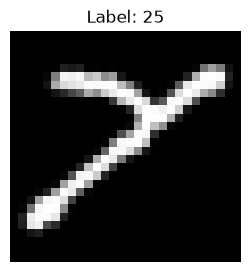

In [45]:
plt.figure(figsize=(3, 3))

plt.imshow(image[:, :, 0], cmap="gray")
plt.title(f"Label: {label.numpy()}")
plt.axis("off")

plt.show()

In [46]:
print(image)

tf.Tensor(
[[[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  1]
  [  1]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  1]
  [ 32]
  [ 26]
  [ 32]
  [  3]
  [  

In [47]:
print(image.shape)

(28, 28, 1)


In [48]:
print(image[0, 0, 0])

tf.Tensor(0, shape=(), dtype=uint8)


In [49]:
print("Minimum pixel value:", tf.reduce_min(image).numpy())
print("Maximum pixel value:", tf.reduce_max(image).numpy())

Minimum pixel value: 0
Maximum pixel value: 255


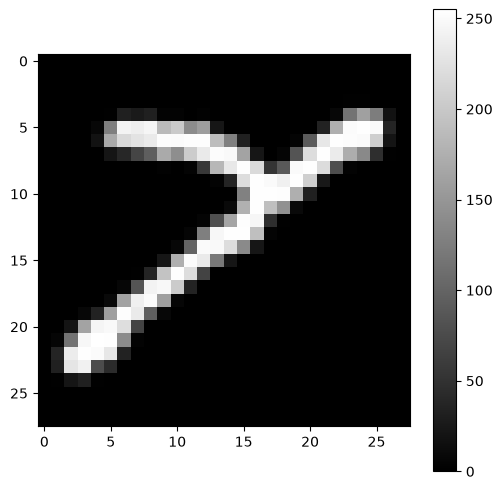

In [50]:
plt.figure(figsize=(6, 6))

plt.imshow(image[:, :, 0], cmap="gray")
plt.colorbar()

plt.show()

In [51]:
normalized_image = tf.cast(image, tf.float32) / 255.0

In [52]:
print("Original minimum:", tf.reduce_min(image).numpy())
print("Original maximum:", tf.reduce_max(image).numpy())

print("Normalized minimum:", tf.reduce_min(normalized_image).numpy())
print("Normalized maximum:", tf.reduce_max(normalized_image).numpy())

Original minimum: 0
Original maximum: 255
Normalized minimum: 0.0
Normalized maximum: 1.0


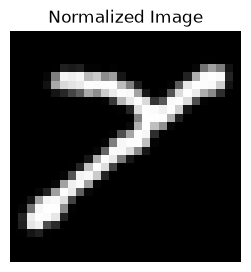

In [53]:
plt.figure(figsize=(3, 3))

plt.imshow(normalized_image[:, :, 0], cmap="gray")
plt.title("Normalized Image")
plt.axis("off")

plt.show()

In [54]:
print("Original pixel:", image[10, 20, 0].numpy())
print("Normalized pixel:", normalized_image[10, 20, 0].numpy())

Original pixel: 33
Normalized pixel: 0.12941177


In [55]:
print("Number of classes:", info.features["label"].num_classes)

Number of classes: 37


In [56]:
print(info.features["label"].names)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36']


In [57]:
label_number = label.numpy()

label_name = info.features["label"].names[label_number]

print("Label number:", label_number)
print("Letter:", label_name)

Label number: 25
Letter: 25


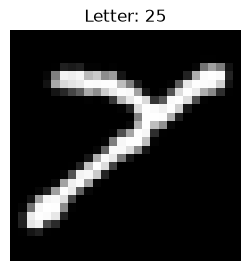

In [58]:
plt.figure(figsize=(3, 3))

plt.imshow(image[:, :, 0], cmap="gray")
plt.title(f"Letter: {label_name}")
plt.axis("off")

plt.show()

In [59]:
unique_labels = set()

for _, label_value in train_dataset:
    unique_labels.add(label_value.numpy().item())

print("Labels found:", sorted(unique_labels))
print("Number of labels found:", len(unique_labels))

Labels found: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
Number of labels found: 26


In [60]:
sorted(unique_labels)

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26]

In [61]:
from collections import Counter

label_counts = Counter()

for _, label_value in train_dataset:
    label_counts[label_value.numpy().item()] += 1

print(label_counts)

Counter({25: 3453, 11: 3438, 24: 3437, 5: 3437, 20: 3436, 17: 3435, 16: 3430, 9: 3428, 26: 3427, 8: 3424, 23: 3423, 22: 3422, 18: 3419, 21: 3419, 3: 3419, 12: 3415, 15: 3408, 10: 3402, 13: 3402, 4: 3398, 2: 3396, 1: 3396, 6: 3394, 19: 3392, 7: 3385, 14: 3365})


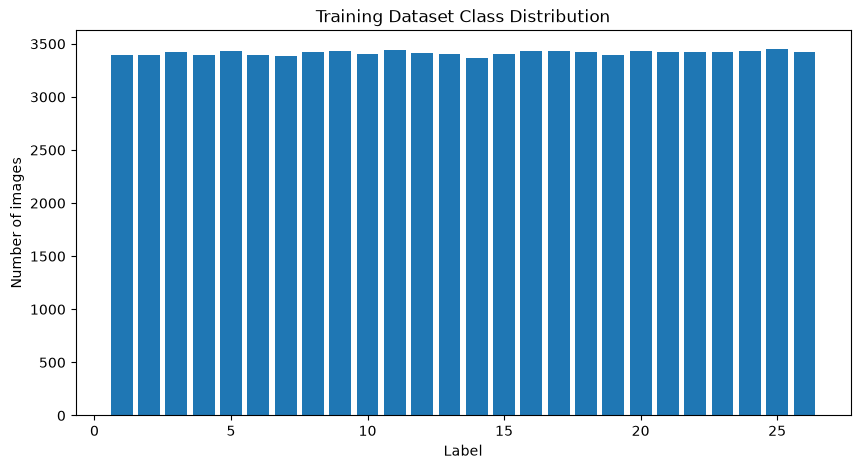

In [62]:
labels = sorted(label_counts.keys())
counts = [label_counts[label] for label in labels]

plt.figure(figsize=(10, 5))

plt.bar(labels, counts)

plt.xlabel("Label")
plt.ylabel("Number of images")
plt.title("Training Dataset Class Distribution")

plt.show()

In [63]:
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    label = label - 1

    return image, label

In [64]:
train_dataset = train_dataset.map(preprocess)

In [65]:
test_dataset = dataset["test"].map(preprocess)

In [66]:
for image, label in train_dataset.take(1):
    print("Shape:", image.shape)
    print("Minimum:", tf.reduce_min(image).numpy())
    print("Maximum:", tf.reduce_max(image).numpy())
    print("Label:", label.numpy())

Shape: (28, 28, 1)
Minimum: 0.0
Maximum: 1.0
Label: 24


In [67]:
BATCH_SIZE = 32

train_dataset = train_dataset.shuffle(10000)
train_dataset = train_dataset.batch(BATCH_SIZE)

test_dataset = test_dataset.batch(BATCH_SIZE)

In [68]:
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 28, 28, 1)
Labels shape: (32,)


In [69]:
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

In [71]:
for images, labels in train_dataset.take(1):
    print("Minimum label:", tf.reduce_min(labels).numpy())
    print("Maximum label:", tf.reduce_max(labels).numpy())
    print("Labels:", labels.numpy())

Minimum label: 1
Maximum label: 25
Labels: [ 4 18  5 16 20  9 25 23  8 23  6 23 14  7 25  6 24 22 18 18  1 24 10  3
 18  4 25 25 11 10 14  1]


# Building the CNN

In [72]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),

    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),

    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dense(26, activation="softmax")
])

In [73]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,098 (887.10 KB)

 Trainable params: 227,098 (887.10 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [75]:
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset
)

Epoch 1/10


C:\Users\fajse\Documents\code\handwritten-alphabet-recognizer\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


2775/2775 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - accuracy: 0.8503 - loss: 0.4743 - val_accuracy: 0.8814 - val_loss: 0.3518
Epoch 2/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9206 - loss: 0.2406 - val_accuracy: 0.9064 - val_loss: 0.2744
Epoch 3/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9351 - loss: 0.1902 - val_accuracy: 0.9199 - val_loss: 0.2406
Epoch 4/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9434 - loss: 0.1599 - val_accuracy: 0.9165 - val_loss: 0.2492
Epoch 5/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9505 - loss: 0.1352 - val_accuracy: 0.9175 - val_loss: 0.2504
Epoch 6/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9556 - loss: 0.1181 - val_accuracy: 0.9209 - val_loss: 0.2492
Epoch 7/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9602 - loss: 0.1017 - val_accuracy: 0.9176 - val_loss: 0.2761
Epoch 8/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.9641 - loss: 0.0903 - va

In [76]:
print("Final training accuracy:", history.history["accuracy"][-1])
print("Final validation accuracy:", history.history["val_accuracy"][-1])

Final training accuracy: 0.9694482088088989
Final validation accuracy: 0.9152026772499084


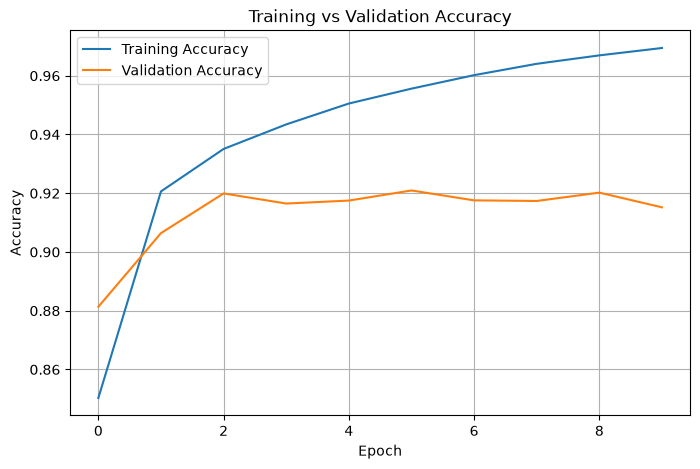

In [77]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

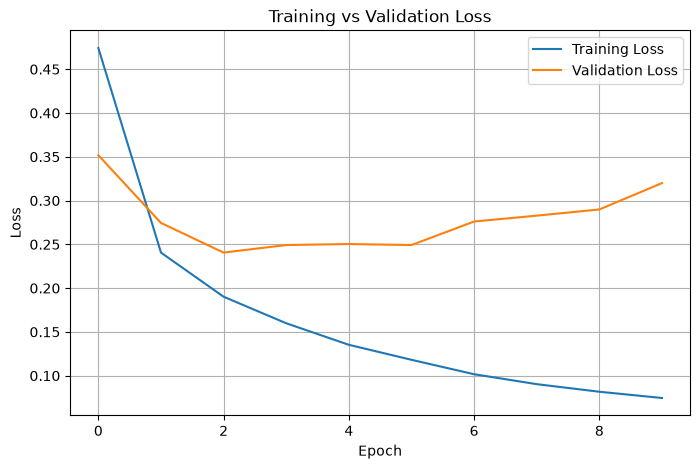

In [78]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

In [79]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

463/463 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9152 - loss: 0.3199
Test loss: 0.3199370205402374
Test accuracy: 0.9152026772499084
